In [1]:
from IPython.display import HTML, display

import tensorflow as tf
import tensorflow_datasets as tfds

import matplotlib.pyplot as plt
%matplotlib inline

2024-03-27 00:46:38.104860: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9373] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-03-27 00:46:38.104967: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-03-27 00:46:38.108294: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1534] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-03-27 00:46:38.125645: I tensorflow/core/platform/cpu_feature_guard.cc:183] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/root/.local/lib/python3.10/site-packag

In [2]:
# set up plotting the training history as a helper function to save repeating it later
def plot_history(history, model_name):
    acc = history['accuracy']
    val_acc = history['val_accuracy']
    loss = history['loss']
    val_loss = history['val_loss']

    epochs = range(1,len(acc)+1)
    plt.figure()
    plt.plot(epochs, acc, 'ro', label='Training acc')
    plt.plot(epochs, val_acc, 'b', label='Validation acc')
    plt.title(f"{model_name} training and validation accuracy")
    plt.legend()  # Automatic detection of elements to be shown in the legend
    plt.xlabel('Epochs')
    plt.xticks(epochs)
    plt.ylabel('Accuracy')
    plt.show()
    
    plt.figure()
    plt.plot(epochs, loss, 'ro', label='Training loss')
    plt.plot(epochs, val_loss, 'b', label='Validation loss')
    plt.title(f"{model_name} training and validation loss")
    plt.xlabel('Epochs')
    plt.xticks(epochs)
    plt.ylabel('Loss')
    plt.legend()  # Automatic detection of elements to be shown in the legend
    plt.show()

# and the pretty_cm function from earlier in the block
def pretty_cm(cm, class_names):
    ncols = len(class_names) + 2
    result_table  = '<h3>Confusion matrix</h3>\n'
    result_table += '<table border=1>\n'
    result_table += f'<tr><td>&nbsp;</td><td>&nbsp;</td><th colspan={ncols}>Predicted labels</th></tr>\n'
    result_table += '<tr><td>&nbsp;</td><td>&nbsp;</td>'

    for cn in class_names:
        result_table += f'<td><strong>{class_names[cn]}</strong></td>'
    result_table += '</tr>\n'

    result_table += '<tr>\n'
    result_table += f'<th rowspan={ncols}>Actual labels</th>\n'

    for ai, an in enumerate(class_names):
        result_table += '<tr>\n'
        result_table += f'  <td><strong>{class_names[an]}</strong></td>\n'
        for pi, pn in enumerate(class_names):
            result_table += f'  <td>{cm[ai, pi]}</td>\n'
        result_table += '</tr>\n'
    result_table += "</table>"
    # print(result_table)
    display(HTML(result_table))

# set up some more detailed metrics, code from Evaluating_models_with_precision_and_recall.ipynb
METRICS = [
      lambda : tf.keras.metrics.TruePositives(name='tp'),
      lambda : tf.keras.metrics.FalsePositives(name='fp'),
      lambda : tf.keras.metrics.TrueNegatives(name='tn'),
      lambda : tf.keras.metrics.FalseNegatives(name='fn'), 

      lambda : tf.keras.metrics.BinaryAccuracy(name='accuracy'),
      lambda : tf.keras.metrics.Precision(name='precision'),
      lambda : tf.keras.metrics.Recall(name='recall'),
      lambda : tf.keras.metrics.AUC(name='auc'),
]

def fresh_metrics():
    return [metric() for metric in METRICS]           

# set up a helper function to evaluate models and summarise training
def eval_model(model_name, model, hist):
    # recompile the model with fresh_metrics
    model.compile(metrics=fresh_metrics())
    
    # then summarise and evaluate on validation/test data
    print(f"{model_name} summary")
    model.summary()
    print(f"\n{model_name} evaluation on validation data")
    results = model.evaluate(val_ds, return_dict=True, verbose=0)
    [print(f"{metric}: {score}") for metric,score in results.items()] 
    print(f"\n{model_name} evaluation on test data")
    results = model.evaluate(test_ds, return_dict=True, verbose=0)
    [print(f"{metric}: {score}") for metric,score in results.items()] 
    
    # now print the history
    print(f"\n{model_name} training history")
    plot_history(hist,model_name)
    #print(f"\n{model_name} confusion matrix (on test data)")
    
    # return the results against test data as we'll export it at the end
    return results

In [3]:
image_size=512
batch_size=16

# since we're resizing we can rescale up here rather than in the model
def resize_and_rescale(image, label):
  image = tf.cast(image, tf.float32)
  image = tf.image.resize(image, [image_size, image_size])
  image = (image / 255.0)
  return image, label

2024-03-27 00:46:41.381775: W external/local_tsl/tsl/platform/cloud/google_auth_provider.cc:184] All attempts to get a Google authentication bearer token failed, returning an empty token. Retrieving token from files failed with "NOT_FOUND: Could not locate the credentials file.". Retrieving token from GCE failed with "FAILED_PRECONDITION: Error executing an HTTP request: libcurl code 6 meaning 'Couldn't resolve host name', error details: Could not resolve host: metadata.google.internal".


tfds.core.DatasetInfo(
    name='image_folder',
    full_name='image_folder/1.0.0',
    description="""
    Generic image classification dataset.
    """,
    homepage='https://www.tensorflow.org/datasets/catalog/image_folder',
    data_dir='/root/tensorflow_datasets/image_folder/1.0.0',
    file_format=tfrecord,
    download_size=Unknown size,
    dataset_size=Unknown size,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'image/filename': Text(shape=(), dtype=string),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    splits={
        'test': <SplitInfo num_examples=1320, num_shards=1>,
        'train': <SplitInfo num_examples=6160, num_shards=1>,
        'validation': <SplitInfo num_examples=1320, num_shards=1>,
    },
    citation="""""",
)


2024-03-27 00:46:41.893469: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-03-27 00:46:41.914624: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-03-27 00:46:41.914667: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-03-27 00:46:41.917122: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-03-27 00:46:41.917170: I external/local_xla/xla/stream_executor

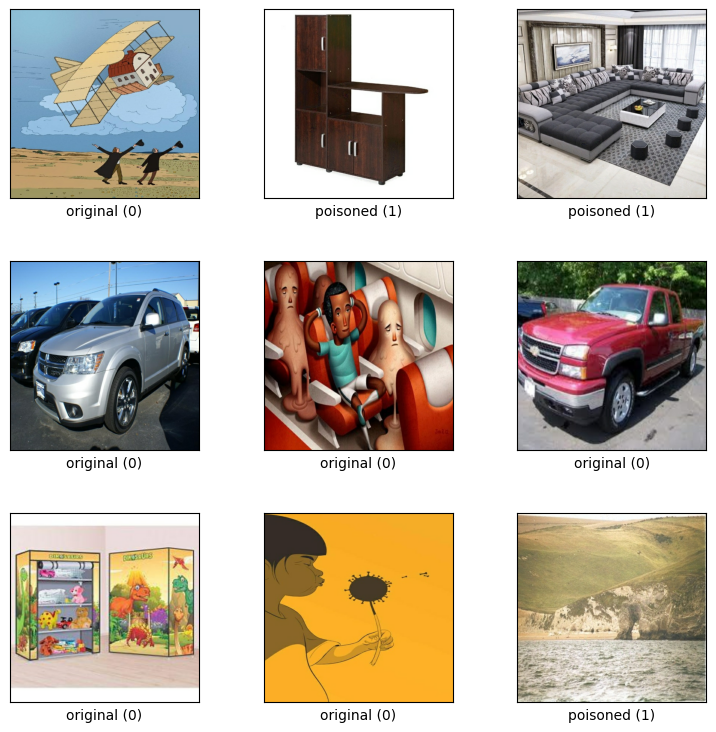

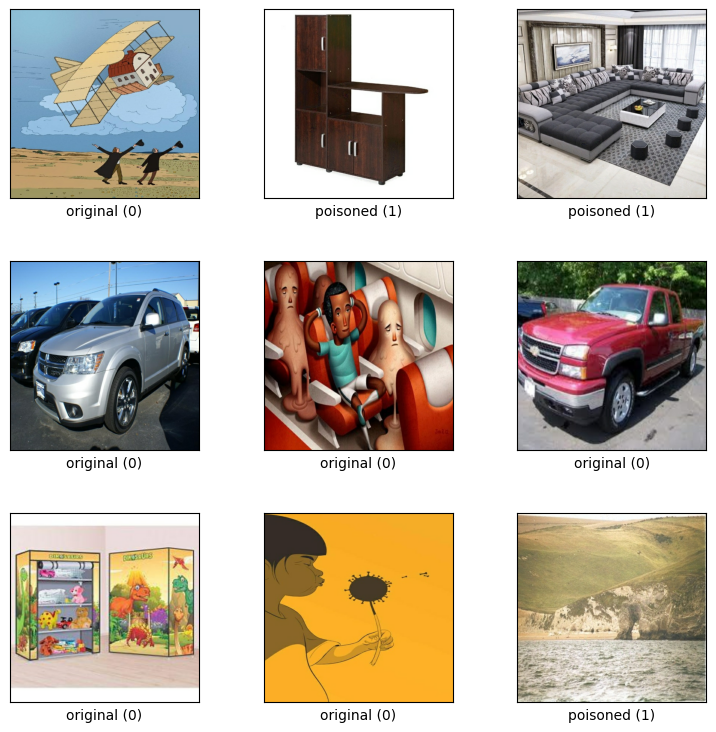

In [4]:
# load the dataset, print a summary and display some samples
# see https://www.tensorflow.org/datasets/api_docs/python/tfds
builder = tfds.ImageFolder('130kv2')
print(builder.info)  # num examples, labels... are automatically calculated
#train_ds = builder.as_dataset(split='train', batch_size=batch_size, shuffle_files=True, as_supervised=True).map(lambda x, y: (resize_and_rescale(x, y))).prefetch(tf.data.AUTOTUNE)
#test_ds = builder.as_dataset(split='test', batch_size=batch_size, shuffle_files=True, as_supervised=True).map(lambda x, y: (resize_and_rescale(x, y))).prefetch(tf.data.AUTOTUNE)
#val_ds = builder.as_dataset(split='validation', batch_size=batch_size, shuffle_files=True, as_supervised=True).map(lambda x, y: (resize_and_rescale(x, y))).prefetch(tf.data.AUTOTUNE)
train_ds = builder.as_dataset(split='train', batch_size=batch_size, shuffle_files=True, as_supervised=True).prefetch(tf.data.AUTOTUNE)
test_ds = builder.as_dataset(split='test', batch_size=batch_size, shuffle_files=True, as_supervised=True).prefetch(tf.data.AUTOTUNE)
val_ds = builder.as_dataset(split='validation', batch_size=batch_size, shuffle_files=True, as_supervised=True).prefetch(tf.data.AUTOTUNE)
tfds.show_examples(train_ds, builder.info, True)

In [5]:
# add some minor augmentation, avoiding anything which might rescale or otherwise impact perturbations
# see https://keras.io/examples/vision/image_classification_from_scratch/
data_augmentation_layers = tf.keras.Sequential([
    #tf.keras.layers.Normalization(),
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
])

def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

In [6]:
def make_model(input_shape, num_classes):
    inputs = tf.keras.Input(shape=input_shape)

    # Entry block
    x = data_augmentation_layers(inputs)
    x = tf.keras.layers.Rescaling(1.0 / 255)(x)
    x = tf.keras.layers.Conv2D(128, 3, strides=2, padding="same")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)

    previous_block_activation = x  # Set aside residual

    for size in [256, 512]:
        x = tf.keras.layers.Activation("relu")(x)
        x = tf.keras.layers.SeparableConv2D(size, 3, padding="same")(x)
        x = tf.keras.layers.BatchNormalization()(x)

        x = tf.keras.layers.Activation("relu")(x)
        x = tf.keras.layers.SeparableConv2D(size, 3, padding="same")(x)
        x = tf.keras.layers.BatchNormalization()(x)

        x = tf.keras.layers.MaxPooling2D(3, strides=2, padding="same")(x)

        # Project residual
        residual = tf.keras.layers.Conv2D(size, 1, strides=2, padding="same")(
            previous_block_activation
        )
        x = tf.keras.layers.add([x, residual])  # Add back residual
        previous_block_activation = x  # Set aside next residual

    x = tf.keras.layers.SeparableConv2D(1024, 3, padding="same")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    if num_classes == 2:
        units = 1
    else:
        units = num_classes

    x = tf.keras.layers.Dropout(0.25)(x)
    # We specify activation=None so as to return logits
    outputs = tf.keras.layers.Dense(units, activation=None)(x)
    return tf.keras.Model(inputs, outputs)


model = make_model(input_shape=(image_size,image_size) + (3,), num_classes=2)
#tf.keras.utils.plot_model(model, show_shapes=True)

In [7]:
epochs = 25

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("save_at_{epoch}.keras"),
]
model.compile(
    optimizer=tf.keras.optimizers.Adam(3e-4),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=[tf.keras.metrics.BinaryAccuracy(name="accuracy")],
)
model_history = model.fit(
    train_ds,
    epochs=epochs,
    #callbacks=callbacks,
    validation_data=val_ds,
).history

Epoch 1/25


2024-03-27 00:46:47.687950: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:467] Loaded cuDNN version 90000
2024-03-27 00:46:52.076230: I external/local_xla/xla/service/service.cc:168] XLA service 0x7fd3ecc46f10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-03-27 00:46:52.076299: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 3090, Compute Capability 8.6
2024-03-27 00:46:52.082219: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1711500412.160796   13429 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


385/385 [==============================] - 151s 349ms/step - loss: 0.7349 - accuracy: 0.5093 - val_loss: 0.6987 - val_accuracy: 0.5000
Epoch 2/25
385/385 [==============================] - 94s 243ms/step - loss: 0.7151 - accuracy: 0.5091 - val_loss: 0.8250 - val_accuracy: 0.5212
Epoch 3/25
385/385 [==============================] - 94s 243ms/step - loss: 0.6064 - accuracy: 0.6545 - val_loss: 0.9852 - val_accuracy: 0.5182
Epoch 4/25
385/385 [==============================] - 93s 243ms/step - loss: 0.4731 - accuracy: 0.7716 - val_loss: 0.4019 - val_accuracy: 0.8242
Epoch 5/25
385/385 [==============================] - 93s 242ms/step - loss: 0.3453 - accuracy: 0.8407 - val_loss: 0.7063 - val_accuracy: 0.6864
Epoch 6/25
385/385 [==============================] - 93s 242ms/step - loss: 0.2564 - accuracy: 0.8847 - val_loss: 0.4495 - val_accuracy: 0.8356
Epoch 7/25
385/385 [==============================] - 93s 242ms/step - loss: 0.2055 - accuracy: 0.9119 - val_loss: 0.3036 - val_accuracy: 0.

initial_model summary
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 512, 512, 3)]        0         []                            
                                                                                                  
 sequential (Sequential)     (None, None, None, 3)        0         ['input_1[0][0]']             
                                                                                                  
 rescaling (Rescaling)       (None, 512, 512, 3)          0         ['sequential[0][0]']          
                                                                                                  
 conv2d (Conv2D)             (None, 256, 256, 128)        3584      ['rescaling[0][0]']           
                                                                        

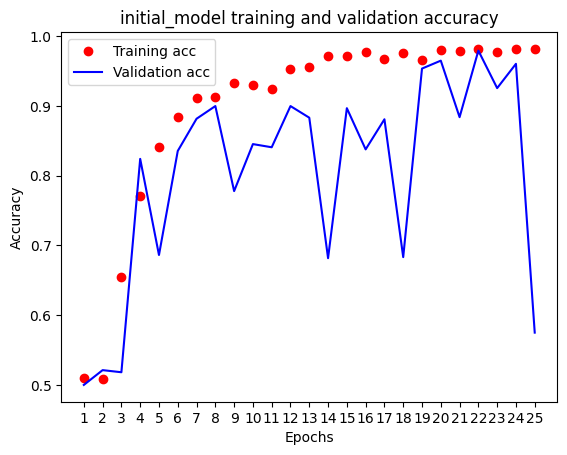

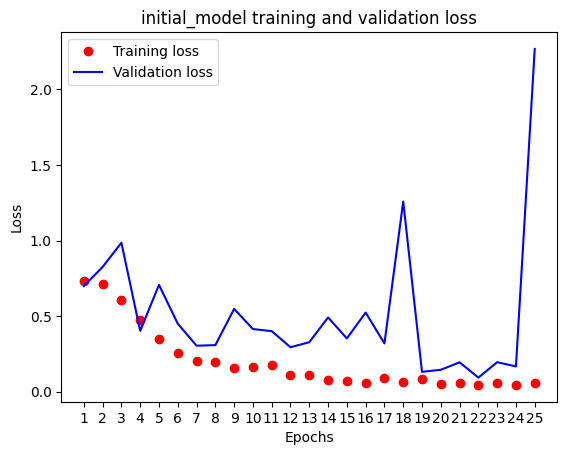

In [8]:
#model = tf.keras.models.load_model('save_at_3.keras')
eval_results = eval_model('initial_model',model,model_history)
#model_history